In [1]:
import numpy as np # Numeric arrays and basic math operations
import pandas as pd  # loading and working with tables (dataframes)

In [2]:
df = pd.read_csv(r"C:\Users\win 10\Downloads\diabetes_130_raw.csv")
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [3]:
# convert target column
df["readmitted"] = np.where(df["readmitted"] == "<30", 1, 0)    #p.where(condition, value_if_true, value_if_false) Here: if "readmitted" equals "<30", assign 1, otherwise 0.
#readmitted column into 0/1: 1 if readmitted within 30 days ("<30"), otherwise 0.

In [4]:
# select features 
features = ["age", "gender", "race", "time_in_hospital", "num_lab_procedures",
            "num_medications", "number_inpatient", "insulin", "diabetesMed"]
features

['age',
 'gender',
 'race',
 'time_in_hospital',
 'num_lab_procedures',
 'num_medications',
 'number_inpatient',
 'insulin',
 'diabetesMed']

In [5]:
#important features that actually describe the patient’s health and hospital stay:
#age, gender, race → basic patient info
#time_in_hospital, num_lab_procedures, num_medications → how serious the case was
#number_inpatient, insulin, diabetesMed → medical history and treatment details

In [6]:
X=df[features] 
X             #X, the feature matrix (a DataFrame with only the chosen columns).

,age,gender,race,time_in_hospital,num_lab_procedures,num_medications,number_inpatient,insulin,diabetesMed
0,[0-10),Female,Caucasian,1,41,1,0,No,No
1,[10-20),Female,Caucasian,3,59,18,0,Up,Yes
2,[20-30),Female,AfricanAmerican,2,11,13,1,No,Yes
3,[30-40),Male,Caucasian,2,44,16,0,Up,Yes
4,[40-50),Male,Caucasian,1,51,8,0,Steady,Yes
...,...,...,...,...,...,...,...,...,...
101761,[70-80),Male,AfricanAmerican,3,51,16,0,Down,Yes
101762,[80-90),Female,AfricanAmerican,5,33,18,1,Steady,Yes
101763,[70-80),Male,Caucasian,1,53,9,0,Down,Yes
101764,[80-90),Female,Caucasian,10,45,21,1,Up,Yes


In [7]:
y=df["readmitted"]
y         #y, the target vector (readmission label 0/1)

0         0
1         0
2         0
3         0
4         0
         ..
101761    0
101762    0
101763    0
101764    0
101765    0
Name: readmitted, Length: 101766, dtype: int64

In [8]:
#Handle categorical and numeric columns
#columns in X that are numeric (integer or float) and stores their names in num_cols.
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
num_cols

Index(['time_in_hospital', 'num_lab_procedures', 'num_medications',
       'number_inpatient'],
      dtype='object')

In [9]:
#columns in X that are of type object (usually strings / categories) and stores names in cat_cols.
cat_cols = X.select_dtypes(include=["object"]).columns
cat_cols

Index(['age', 'gender', 'race', 'insulin', 'diabetesMed'], dtype='object')

In [10]:
from sklearn.pipeline import Pipeline          
#A Pipeline connects multiple preprocessing or modeling steps together.
from sklearn.impute import SimpleImputer       
# Imputer means something that fills in missing values in your dataset.
#The SimpleImputer is used to handle NaN (missing) data.
from sklearn.preprocessing import OneHotEncoder, StandardScaler
#OneHotEncoder Used for categorical (text) data.
#It converts words like "Male", "Female", "Other" into numbers the model can understand.
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])    
numeric_transformer         # makes numeric values clean and balanced

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])

In [11]:
categorical_transformer=Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
categorical_transformer      # makes text data understandable for the ML model.

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

("num", numeric_transformer, num_cols)
"num" is just a name for this step.
numeric_transformer is the small pipeline.

("cat", categorical_transformer, cat_cols)
"cat" is the name for categorical columns.
categorical_transformer is the pipeline you made for text columns.

In [12]:
#imports the ColumnTransformer tool from scikit-learn.
#We use it when our dataset has different types of columns —
#some are numeric (numbers) and some are categorical (text) —
#and we need to apply different preprocessing steps to each type.

from sklearn.compose import ColumnTransformer
preprocessor=ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])  
preprocessor      #To handle all columns together efficiently and cleanly.

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 Index(['time_in_hospital', 'num_lab_procedures', 'num_medications',
       'number_inpatient'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['age', 'gender', 'race', 'insulin', 'diabetesMed'], dtype='object'))])

#### Why we are using all this three numeric_transformer,categorical_transformer,preprocessor?

1. numeric_transformer:-
Handles number data only.
Example: age, time_in_hospital, num_medications

 Removes missing numbers using the mean
 Scales all numbers to a similar range using StandardScaler

2. categorical_transformer:-
Handles text/categorical data only.
Example: gender, race, insulin
Fills missing values using the most frequent value
Converts text into numeric form using OneHotEncoder

3. Preprocessing:-
This combines both transformers into one single step.
It tells the computer which columns are numeric and which are categorical.
It runs both transformers at once and merges the output.

In [13]:
# Split data (time-based split not shown here, can use random for simplicity)
#train_test_split divides the dataset into training (80%) and testing (20%) sets so 
#we can train the model on one part and test it on unseen data to measure accuracy.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)
X_train

,age,gender,race,time_in_hospital,num_lab_procedures,num_medications,number_inpatient,insulin,diabetesMed
24079,[70-80),Female,Caucasian,4,48,11,0,No,No
98079,[50-60),Male,Caucasian,1,42,5,0,No,No
6237,[80-90),Male,Caucasian,4,44,10,0,No,Yes
72208,[80-90),Male,Caucasian,3,54,8,0,Steady,Yes
33075,[70-80),Female,AfricanAmerican,11,35,23,1,No,No
...,...,...,...,...,...,...,...,...,...
6265,[70-80),Male,Caucasian,2,35,12,0,No,No
54886,[60-70),Male,Caucasian,5,63,23,0,Up,Yes
76820,[70-80),Male,Caucasian,3,55,33,0,Down,Yes
860,[60-70),Female,Caucasian,12,77,21,0,Down,Yes


"Random Forest": RandomForestClassifier(random_state=42)
Random Forest is an ensemble model — it builds many decision trees and combines their results.
It’s great for mixed data (numbers + text) and handles missing values well.
random_state=42 makes results consistent every time you run it.

Why use it: It’s powerful, accurate, and works well for healthcare data.

2️"XGBoost": XGBClassifier(...)
XGBoost stands for Extreme Gradient Boosting — it’s a very fast and powerful boosting model.
It builds trees one after another, each correcting the previous one’s mistakes.
Parameters:
use_label_encoder=False → avoids a warning
eval_metric="logloss" → defines how model performance is measured
random_state=42 → ensures reproducibility

Why use it: It’s one of the best models for tabular (structured) data and often gives very high accuracy.
"SVM": SVC(probability=True, random_state=42)
SVM (Support Vector Machine) tries to find a boundary (line/plane) that separates the two classes (e.g., readmitted vs. not readmitted).
probability=True means it can also give probability scores (e.g., 0.8 chance of readmission).
random_state=42 keeps results stable.

Why use it: It performs well on smaller, clean datasets and gives strong classification accuracy.

In [14]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [15]:
y = (df['readmitted'] != 'NO').astype(int)
y

0         1
1         1
2         1
3         1
4         1
         ..
101761    1
101762    1
101763    1
101764    1
101765    1
Name: readmitted, Length: 101766, dtype: int64

In [16]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

models = {
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss",
                             n_estimators=50, max_depth=4, random_state=42, n_jobs=-1),
    "SVM": SVC(probability=True, kernel='linear', random_state=42)
}

results = {}
models

{'Random Forest': RandomForestClassifier(max_depth=5, n_estimators=50, n_jobs=-1, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=4, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=50, n_jobs=-1,
               num_parallel_tree=None, ...),
 'SVM': SVC(kernel='linear', probability=True, random_state=42)}

In [ ]:
from sklearn.metrics import brier_score_loss, roc_auc_score, classification_report
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=50,   # fewer trees = faster
    max_depth=5,       # limit depth = prevents overfitting
    random_state=42,
    n_jobs=-1          # uses all CPU cores for speed
)

# Build pipeline with preprocessor
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

print("\n🔹 Training Random Forest...")
rf_pipe.fit(X_train, y_train)

#Predict probabilities
y_prob = rf_pipe.predict_proba(X_test)[:, 1]

#Evaluation metrics
brier = brier_score_loss(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print("\n Random Forest Results:")
print("Brier Score:", round(brier, 4))
print("AUC:", round(auc, 4))
print("\nClassification Report:")
print(classification_report(y_test, (y_prob > 0.5).astype(int)))

#Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Random Forest')
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Calibration Curve - Random Forest")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.legend()
plt.grid(True)
plt.show()


🔹 Training XGBoost...


C:\Users\win 10\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:39:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ XGBoost Results:
Brier Score: 0.0967
AUC: 0.6384

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.47      0.01      0.02      2285

    accuracy                           0.89     20354
   macro avg       0.68      0.50      0.48     20354
weighted avg       0.84      0.89      0.84     20354



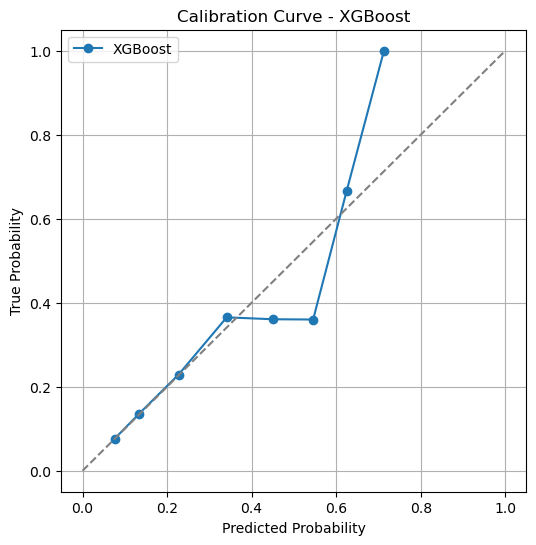

In [22]:
from xgboost import XGBClassifier
# ✅ Create XGBoost model (fast & reliable)
xgb_model = XGBClassifier(
    n_estimators=100,     # number of trees
    max_depth=4,          # control model complexity
    learning_rate=0.1,    # step size
    subsample=0.8,        # random sampling for trees
    colsample_bytree=0.8, # random feature sampling
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

# Build pipeline with preprocessor
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

print("\n🔹 Training XGBoost...")
xgb_pipe.fit(X_train, y_train)

# Predict probabilities
y_prob = xgb_pipe.predict_proba(X_test)[:, 1]

# Evaluation metrics
brier = brier_score_loss(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print("\n XGBoost Results:")
print("Brier Score:", round(brier, 4))
print("AUC:", round(auc, 4))
print("\nClassification Report:")
print(classification_report(y_test, (y_prob > 0.5).astype(int)))

# Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost')
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Calibration Curve - XGBoost")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.svm import SVC

# ✅ Create SVM model (with probability enabled)
svm_model = SVC(
    kernel='rbf',          # default radial basis kernel
    probability=True,      # enables predict_proba
    C=1.0,                 # regularization parameter
    gamma='scale',         # kernel coefficient
    random_state=42
)

# ✅ Build pipeline with preprocessor
svm_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", svm_model)
])

print("\n🔹 Training SVM...")
svm_pipe.fit(X_train, y_train)

# ✅ Predict probabilities
y_prob = svm_pipe.predict_proba(X_test)[:, 1]

# ✅ Evaluation metrics
brier = brier_score_loss(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print("\n✅ SVM Results:")
print("Brier Score:", round(brier, 4))
print("AUC:", round(auc, 4))
print("\nClassification Report:")
print(classification_report(y_test, (y_prob > 0.5).astype(int)))

# ✅ Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='SVM')
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Calibration Curve - SVM")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.legend()
plt.grid(True)
plt.show()